# RFM-Based Customer Segmentation & Revenue Analysis (Superstore Dataset)


**Author:** Daniel Damilola Amosun  
**Brand:** InferaIQ  
**Role:** Data Analyst | Aspiring Data Scientist

This project analyzes customer behavior and sales performance using the Superstore dataset to identify key revenue drivers, segment customers using RFM analysis, and generate actionable business insights to support data-driven decision-making.

---

## Introduction

The retail industry generates large volumes of transactional data, making it essential to understand customer purchasing behavior and revenue patterns. This analysis focuses on exploring sales performance, identifying key trends, and segmenting customers based on their value to the business.

Using the Superstore dataset, this project applies data analysis techniques and RFM (Recency, Frequency, Monetary) segmentation to uncover insights that can support strategic decision-making and improve customer retention.

---

**Dataset:** Sample Superstore  
**Tools:** Python (Pandas, NumPy, Matplotlib, Seaborn)  

---

## 🎯 Objective
- Analyze customer behavior and sales performance.
- Identify operational inefficiencies (e.g., shipping delays).
- Segment customers using **RFM (Recency, Frequency, Monetary)**.
- Produce an **executive-ready visualization** showing revenue concentration.

---

## 🧭 Workflow
1. Data Loading & Audit  
2. Data Cleaning & Feature Engineering  
3. Exploratory Data Analysis (EDA)  
4. RFM Segmentation  
5. Executive Visualization (Power BI–style)  
6. Key Insights & Recommendations


## 📦 Imports & Settings

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

## 📂 Load Data

In [21]:
# Update the path if needed
file_path = "Sample - Superstore.xlsx"
df = pd.read_excel(file_path)

print("Shape:", df.shape)
df.head()


Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2020-152156,2020-11-08,2020-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2020-152156,2020-11-08,2020-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2020-138688,2020-06-12,2020-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 🔎 Data Audit

In [22]:
df.info()
df.describe(include='all')
df.isnull().sum().sort_values(ascending=False).head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9994 non-null   int64         
 1   Order ID        9994 non-null   object        
 2   Order Date      9994 non-null   datetime64[ns]
 3   Ship Date       9994 non-null   datetime64[ns]
 4   Ship Mode       9994 non-null   object        
 5   Customer ID     9994 non-null   object        
 6   Customer Name   9994 non-null   object        
 7   Segment         9994 non-null   object        
 8   Country/Region  9994 non-null   object        
 9   City            9994 non-null   object        
 10  State           9994 non-null   object        
 11  Postal Code     9983 non-null   float64       
 12  Region          9994 non-null   object        
 13  Product ID      9994 non-null   object        
 14  Category        9994 non-null   object        
 15  Sub-

,0
Postal Code,11
Order ID,0
Order Date,0
Ship Date,0
Row ID,0
Ship Mode,0
Customer ID,0
Segment,0
Customer Name,0
Country/Region,0


## 🧹 Data Cleaning & Feature Engineering

In [23]:
# Date parsing
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")

# Remove duplicates (if any)
df = df.drop_duplicates()

# Shipping delay (days)
df["Shipping Delay"] = (df["Ship Date"] - df["Order Date"]).dt.days
df["Shipping Delay"] = df["Shipping Delay"].clip(lower=0)

# Time features
df["Order Month"] = df["Order Date"].dt.to_period("M").astype(str)
df["Order Year"] = df["Order Date"].dt.year

df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Delay,Order Month,Order Year
0,1,CA-2020-152156,2020-11-08,2020-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3,2020-11,2020
1,2,CA-2020-152156,2020-11-08,2020-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3,2020-11,2020
2,3,CA-2020-138688,2020-06-12,2020-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4,2020-06,2020
3,4,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7,2019-10,2019
4,5,US-2019-108966,2019-10-11,2019-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7,2019-10,2019


## 📊 Exploratory Data Analysis

### 1) Monthly Sales Trend

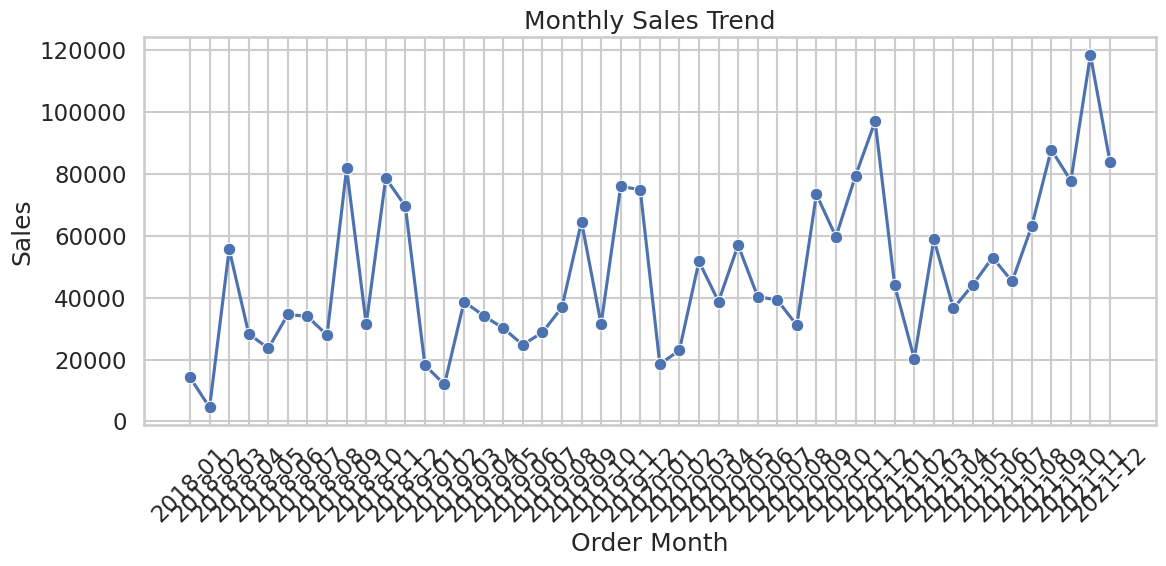

In [24]:
monthly_sales = df.groupby("Order Month")["Sales"].sum().reset_index()

plt.figure()
sns.lineplot(data=monthly_sales, x="Order Month", y="Sales", marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.tight_layout()
plt.show()


### 2) Profit vs Discount

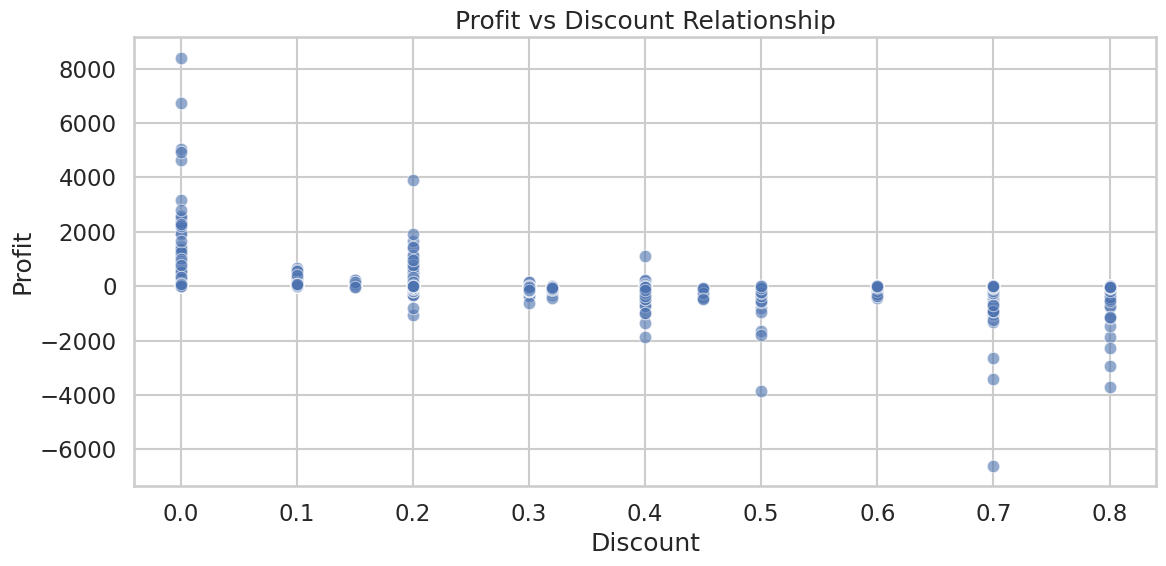

In [25]:
plt.figure()
sns.scatterplot(data=df, x="Discount", y="Profit", alpha=0.6)
plt.title("Profit vs Discount Relationship")
plt.tight_layout()
plt.show()


### 3) Shipping Delay Distribution

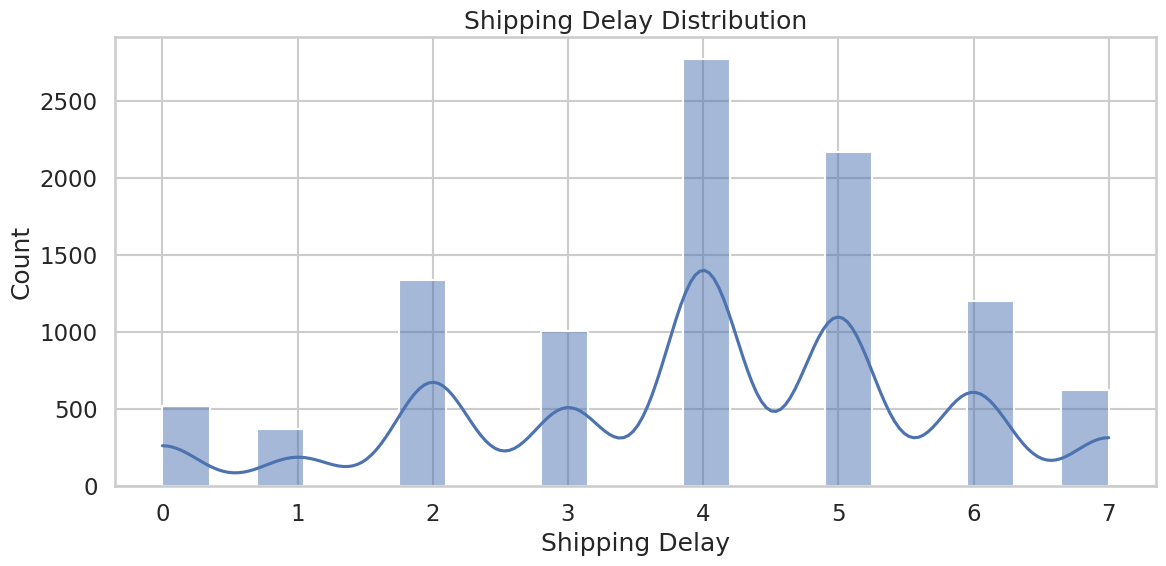

In [26]:
plt.figure()
sns.histplot(df["Shipping Delay"], bins=20, kde=True)
plt.title("Shipping Delay Distribution")
plt.tight_layout()
plt.show()


### 4) Sales by Segment

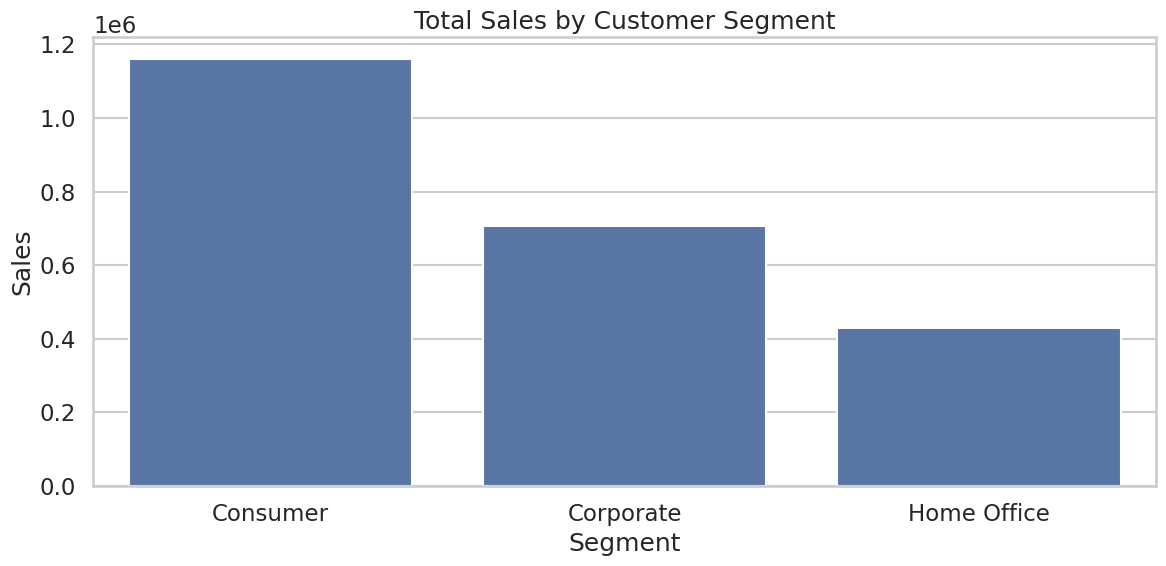

In [27]:
plt.figure()
sns.barplot(data=df, x="Segment", y="Sales", estimator=sum, errorbar=None)
plt.title("Total Sales by Customer Segment")
plt.tight_layout()
plt.show()


## 🔬 RFM Segmentation

In [28]:
# Snapshot date (day after last order)
snapshot_date = df["Order Date"].max() + pd.Timedelta(days=1)

# Build RFM table
rfm = (
    df.groupby("Customer ID")
      .agg({
          "Order Date": lambda x: (snapshot_date - x.max()).days,  # Recency
          "Order ID": "nunique",                                  # Frequency
          "Sales": "sum"                                          # Monetary
      })
      .rename(columns={
          "Order Date": "Recency",
          "Order ID": "Frequency",
          "Sales": "Monetary"
      })
      .reset_index()
)

rfm.head()


,Customer ID,Recency,Frequency,Monetary
0,AA-10315,185,5,5563.560
1,AA-10375,20,9,1056.390
2,AA-10480,260,4,1790.512
3,AA-10645,56,6,5086.935
4,AB-10015,416,3,886.156


In [29]:
# RFM scoring (quartiles)
rfm["R_score"] = pd.qcut(rfm["Recency"], 4, labels=[4,3,2,1])  # lower is better -> higher score
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1,2,3,4])
rfm["M_score"] = pd.qcut(rfm["Monetary"], 4, labels=[1,2,3,4])

rfm.head()


,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score
0,AA-10315,185,5,5563.560,1,1,4
1,AA-10375,20,9,1056.390,4,4,1
2,AA-10480,260,4,1790.512,1,1,2
3,AA-10645,56,6,5086.935,3,2,4
4,AB-10015,416,3,886.156,1,1,1


### 🧠 Business-Friendly Segmentation

In [30]:
# Initialize
rfm["Segment_Clean"] = "Others"

# Champions (priority - do first to avoid overwrite)
rfm.loc[
    (rfm["R_score"].astype(int) >= 3) &
    (rfm["F_score"].astype(int) >= 3) &
    (rfm["M_score"].astype(int) >= 3),
    "Segment_Clean"
] = "Champions"

# Loyal Customers (exclude Champions)
rfm.loc[
    (rfm["Segment_Clean"] != "Champions") &
    (rfm["F_score"].astype(int) >= 3) &
    (rfm["M_score"].astype(int) >= 3),
    "Segment_Clean"
] = "Loyal Customers"

# Recent Customers
rfm.loc[
    (rfm["Segment_Clean"] == "Others") &
    (rfm["R_score"].astype(int) == 4),
    "Segment_Clean"
] = "Recent Customers"

# At Risk
rfm.loc[
    (rfm["R_score"].astype(int) == 1),
    "Segment_Clean"
] = "At Risk"

rfm["Segment_Clean"].value_counts()


,count
Segment_Clean,
Others,233
At Risk,196
Champions,176
Recent Customers,111
Loyal Customers,77


## 🏆 Executive Visualization — Revenue by Customer Segment

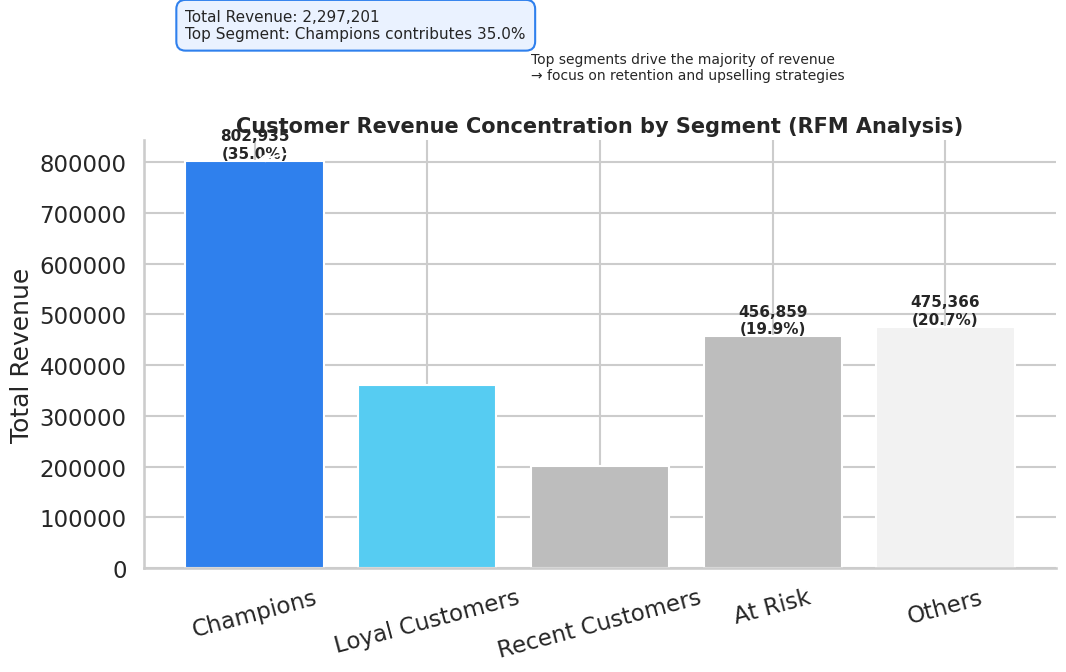

In [31]:
# =========================================
# Executive Visualization — Revenue by Customer Segment
# =========================================

# Aggregate revenue by segment
seg_rev = (
    rfm.groupby("Segment_Clean")["Monetary"]
       .sum()
       .reset_index()
)

# Calculate percentage contribution
total = seg_rev["Monetary"].sum()
seg_rev["Percent"] = seg_rev["Monetary"] / total * 100

# Identify top segment
top_segment = seg_rev.loc[seg_rev["Monetary"].idxmax(), "Segment_Clean"]
top_percent = seg_rev["Percent"].max()

# Define business-driven segment order
segment_order = [
    "Champions",
    "Loyal Customers",
    "Recent Customers",
    "At Risk",
    "Others"
]

seg_rev["Segment_Clean"] = pd.Categorical(
    seg_rev["Segment_Clean"],
    categories=segment_order,
    ordered=True
)

seg_rev = seg_rev.sort_values("Segment_Clean").reset_index(drop=True)

# Define color hierarchy
colors = []
for seg in seg_rev["Segment_Clean"]:
    if seg == "Champions":
        colors.append("#2F80ED")
    elif seg == "Loyal Customers":
        colors.append("#56CCF2")
    elif seg == "Others":
        colors.append("#F2F2F2")
    else:
        colors.append("#BDBDBD")

# Create chart
plt.figure(figsize=(11, 6))
bars = plt.bar(seg_rev["Segment_Clean"], seg_rev["Monetary"], color=colors)

# Label TOP 3 segments by revenue (correct & intentional)
top3_segments = seg_rev.sort_values("Monetary", ascending=False)["Segment_Clean"].head(3)

for i, bar in enumerate(bars):
    segment = seg_rev.iloc[i]["Segment_Clean"]

    if segment in top3_segments.values:
        value = seg_rev.iloc[i]["Monetary"]
        percent = seg_rev.iloc[i]["Percent"]

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:,.0f}\n({percent:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

# Title and labels
plt.title(
    "Customer Revenue Concentration by Segment (RFM Analysis)",
    fontsize=15,
    fontweight="bold"
)
plt.ylabel("Total Revenue")
plt.xticks(rotation=15)

# Clean styling
sns.despine()
plt.tight_layout()

# KPI summary box
plt.text(
    -0.4,
    max(seg_rev["Monetary"]) * 1.3,
    f"Total Revenue: {total:,.0f}\nTop Segment: {top_segment} contributes {top_percent:.1f}%",
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="#EAF2FF",
        edgecolor="#2F80ED"
    )
)

# Insight annotation
plt.annotate(
    "Top segments drive the majority of revenue\n→ focus on retention and upselling strategies",
    xy=(bars[0].get_x() + bars[0].get_width()/2, bars[0].get_height()),
    xytext=(1.6, max(seg_rev["Monetary"]) * 1.2),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

# Save final portfolio image
plt.savefig("rfm_executive_visual.png", dpi=300, bbox_inches="tight")

plt.show()

## 📌 Key Insights

- Revenue is concentrated among a small number of high-value customer segments, with **Champions contributing the largest share (~35%)**.
- **At Risk and Other segments also contribute significantly**, indicating both revenue risk and untapped value opportunities.
- Discounts exhibit a negative relationship with profit in many cases, suggesting margin pressure.
- Shipping delays vary across orders and may negatively impact customer experience.
- A small proportion of customers drives a large share of revenue, reflecting the Pareto principle.

---

## 🚀 Business Recommendations

- Prioritize retention and upselling strategies for **Champions and other high-value segments** to maximize revenue.
- Re-engage **At Risk customers** through targeted campaigns to reduce potential revenue loss.
- Optimize discount strategies to protect profit margins and improve overall profitability.
- Improve logistics performance in areas with higher shipping delays to enhance customer satisfaction and service efficiency.

---

## 🟢 Conclusion

This analysis demonstrates that revenue is concentrated among a limited number of high-value customer segments, with Champions contributing the largest share and At Risk segments representing both value and retention risk.

The findings emphasize the need for targeted retention strategies, pricing optimization, and operational improvements to sustain revenue growth and enhance customer experience.

Overall, this project showcases the application of exploratory data analysis, feature engineering, RFM segmentation, and data visualization to generate actionable insights and support data-driven decision-making.

These insights can inform targeted marketing, customer retention initiatives, and operational optimization to drive sustainable business growth.